# Day 22 - BERT - 双向编码器表示

> 目标: 理解 BERT 的 MLM 预训练 + 双向注意力
>
> 核心: 不再从左到右生成, 而是同时看上下文两边

---

## GPT vs BERT

```
GPT (Day 23):                         BERT (今天):
  从左到右 -> 下一个词预测              双向 -> 填空
  Transformer Decoder                Transformer Encoder
  适合生成 (写文章)                    适合理解 (分类/标注)

  输入: [CLS] 我今天 [SEP]             输入: [CLS] 我 [MASK] 天 [SEP]
  预测: 去上学                         预测: [MASK] = 今
```

### BERT 的两阶段

```
Stage 1: MLM 预训练 (Pre-training)
  在 Wikipedia + BookCorpus (33亿词) 上做填空
  耗时: 4 天 × 4 块 TPU
  目标: 不是做任务, 而是学语言理解能力

Stage 2: 微调 (Fine-tuning)
  在你自己的小数据上训练 1 分钟
  目标: 做具体任务 (分类/问答/标注)
```

In [2]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['HF_ENDPOINT'] = 'https://hf-mirror.com'
os.environ['HF_HOME'] = 'D:\\hyy\\vscode\\vscode模型'

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

print('=' * 40)
print('Day 22 - BERT')
print('=' * 40)

Day 22 - BERT


## 1. 加载 BERT, 看看它怎么理解句子

> 用 HuggingFace 加载已经预训练好的 BERT, 看注意力模式
>
> 不需要从头训练, 直接感受它学到的语言能力

In [4]:
# ============================================
# 加载 BERT tokenizer + 模型
# ============================================

from transformers import BertTokenizer, BertModel, BertForMaskedLM

model_name = 'bert-base-uncased'
print(f'加载 {model_name}...')

tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertModel.from_pretrained(model_name, output_attentions=True)
mlm_model = BertForMaskedLM.from_pretrained(model_name)

print(f'词表大小: {tokenizer.vocab_size}')
print(f'BERT 参数量: {sum(p.numel() for p in model.parameters()):,}')
print(f'层数: {model.config.num_hidden_layers}')
print(f'注意力头: {model.config.num_attention_heads}')
print(f'隐藏维度: {model.config.hidden_size}')

加载 bert-base-uncased...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

[transformers] BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


词表大小: 30522
BERT 参数量: 109,482,240
层数: 12
注意力头: 12
隐藏维度: 768


In [8]:
# ============================================
# 看看 BERT 怎么分词
# ============================================

sentences = [
    'I love deep learning.',
    'BERT is a bidirectional model.',
    'The cat sat on the mat.',
    'I need to print the document',
    'I just want to see you',
    'Can you give me a chance',
    'I am out of touch'
]

inputs = tokenizer(sentences, padding=True, truncation=True, return_tensors='pt')

print('分词结果:')
for i, s in enumerate(sentences):
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][i])
    print(f'  "{s}"')
    print(f'  -> {tokens}')
print(f'  input_ids: {tuple(inputs["input_ids"].shape)}')

分词结果:
  "I love deep learning."
  -> ['[CLS]', 'i', 'love', 'deep', 'learning', '.', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
  "BERT is a bidirectional model."
  -> ['[CLS]', 'bert', 'is', 'a', 'bid', '##ire', '##ction', '##al', 'model', '.', '[SEP]']
  "The cat sat on the mat."
  -> ['[CLS]', 'the', 'cat', 'sat', 'on', 'the', 'mat', '.', '[SEP]', '[PAD]', '[PAD]']
  "I need to print the document"
  -> ['[CLS]', 'i', 'need', 'to', 'print', 'the', 'document', '[SEP]', '[PAD]', '[PAD]', '[PAD]']
  "I just want to see you"
  -> ['[CLS]', 'i', 'just', 'want', 'to', 'see', 'you', '[SEP]', '[PAD]', '[PAD]', '[PAD]']
  "Can you give me a chance"
  -> ['[CLS]', 'can', 'you', 'give', 'me', 'a', 'chance', '[SEP]', '[PAD]', '[PAD]', '[PAD]']
  "I am out of touch"
  -> ['[CLS]', 'i', 'am', 'out', 'of', 'touch', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
  input_ids: (7, 11)


## 2. MLM (Masked Language Model) — 填空测试

> BERT 的训练方式: 随机遮住一些词, 让模型猜
>
> 这迫使模型同时看左右两边的上下文, 实现"双向"

In [10]:
# ============================================
# BERT 填空: 给一个句子, 让 BERT 预测被遮住的词
# ============================================

def predict_mask(sentence_with_mask, top_k=5):
    """让 BERT 预测 [MASK] 位置最可能的词"""
    inputs = tokenizer(sentence_with_mask, return_tensors='pt')
    mask_idx = inputs['input_ids'].squeeze().tolist().index(tokenizer.mask_token_id)

    with torch.no_grad():
        outputs = mlm_model(**inputs)
        logits = outputs.logits[0, mask_idx, :]
        probs = torch.softmax(logits, dim=0)
        top_probs, top_indices = probs.topk(top_k)

    print(f'  句子: {sentence_with_mask}')
    print(f'  预测 top{top_k}:')
    for prob, idx in zip(top_probs, top_indices):
        token = tokenizer.decode([idx])
        print(f'    {token}: {prob.item():.1%}')
    return

print('BERT 填空测试:')
print()
predict_mask('I love [MASK] learning.')
print()
predict_mask('The cat sat on the [MASK].')
print()
predict_mask('I want to [MASK] a book.')
print()
predict_mask('She is [MASK] to school every day.')
predict_mask('I need tp [MASK] the document')
print()
predict_mask('I just want to [MASK] you')
print()
predict_mask('Can you [MASK] me a chance')
print()
predict_mask('I am out of [MASK]')
print()

BERT 填空测试:

  句子: I love [MASK] learning.
  预测 top5:
    about: 16.7%
    the: 15.7%
    your: 10.3%
    my: 5.6%
    just: 5.0%

  句子: The cat sat on the [MASK].
  预测 top5:
    floor: 31.4%
    bed: 11.9%
    couch: 10.7%
    sofa: 6.0%
    ground: 5.5%

  句子: I want to [MASK] a book.
  预测 top5:
    write: 47.6%
    read: 40.1%
    open: 1.9%
    buy: 1.7%
    be: 1.0%

  句子: She is [MASK] to school every day.
  预测 top5:
    going: 69.4%
    coming: 10.1%
    sent: 2.5%
    late: 1.7%
    walking: 1.5%
  句子: I need tp [MASK] the document
  预测 top5:
    for: 31.7%
    on: 24.7%
    in: 15.0%
    from: 10.3%
    with: 2.5%

  句子: I just want to [MASK] you
  预测 top5:
    see: 19.5%
    hold: 17.2%
    tell: 7.8%
    touch: 6.0%
    kiss: 5.3%

  句子: Can you [MASK] me a chance
  预测 top5:
    give: 99.7%
    buy: 0.1%
    offer: 0.1%
    giving: 0.0%
    gives: 0.0%

  句子: I am out of [MASK]
  预测 top5:
    .: 97.2%
    !: 1.5%
    ;: 1.1%
    ?: 0.2%
    ...: 0.0%



## 3. 可视化 BERT 的双向注意力

> 看 BERT 每层每个头的注意力, 理解"双向"的含义
>
> 对比: GPT 只能是"只看左边", BERT "同时看两边"

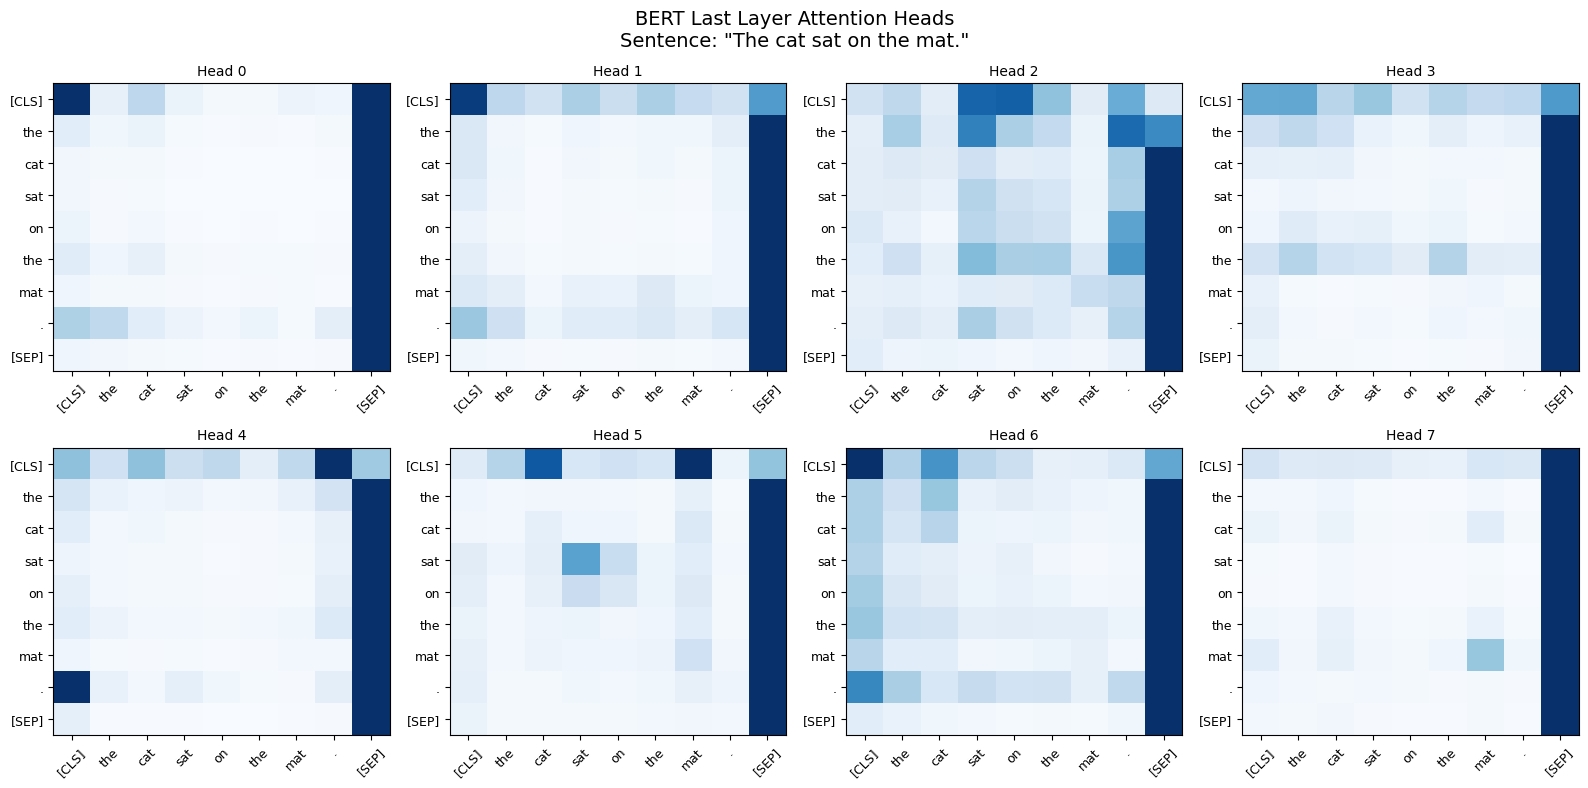

观察:
  - 每个位置都能看到所有位置 (双向!)
  - 不同头关注不同的语法关系
  - 局部 Head 聚焦对角线（语法搭配），全局 Head 聚焦分散区域（长距离语义）


In [12]:
# ============================================
# 提取 BERT 某一层的注意力权重并可视化
# ============================================
import torch
import matplotlib.pyplot as plt
# 假设前面已经加载了 tokenizer 和 model

sentence = 'The cat sat on the mat.'
inputs = tokenizer(sentence, return_tensors='pt')

with torch.no_grad():
    # output_attentions=True 确保模型返回注意力权重
    outputs = model(**inputs, output_attentions=True) 

# 取最后一层, 头 0 的注意力
attentions = outputs.attentions  # tuple of 12 layers
last_layer_attn = attentions[-1][0]  # (num_heads, seq_len, seq_len)

tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
n = len(tokens)

# 【核心概念补充 1：Attention Mask 是什么？】
# 在 BERT 等 Transformer 模型中，输入句子的长度往往不一致。为了并行计算，我们会对短句子进行填充（Padding）。
# Attention Mask 是一个由 0 和 1 组成的矩阵（或向量），用来告诉模型哪些是真正的词，哪些是填充的 [PAD]。
# 在计算注意力分数时，模型会将 [PAD] 位置的分数强制设为负无穷（-inf），这样经过 Softmax 后，
# 模型对 [PAD] 的注意力权重就会变为 0，从而避免模型去“关注”毫无意义的填充字符。

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

# 遍历前8个注意力头进行可视化
for head_idx in range(min(8, last_layer_attn.shape[0])):
    ax = axes[head_idx]
    attn_matrix = last_layer_attn[head_idx, :n, :n].numpy()
    im = ax.imshow(attn_matrix, cmap='Blues', aspect='auto', vmin=0, vmax=0.3)
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(tokens, fontsize=9, rotation=45)
    ax.set_yticklabels(tokens, fontsize=9)
    ax.set_title(f'Head {head_idx}', fontsize=10)

plt.suptitle(f'BERT Last Layer Attention Heads\nSentence: "{sentence}"', fontsize=14)
plt.tight_layout()
plt.savefig('day22_bert_attention.png', dpi=150)
plt.show()

# 【核心概念补充 2：不同 Attention Head 的关注模式】
# BERT 的多个注意力头（Attention Heads）会自动分工，关注不同层级的语言特征：
# 
# 1. 主要关注相邻词（局部/语法依赖）的 Head：
#    - 表现：热力图中，颜色主要集中在对角线及其附近。
#    - 作用：捕捉局部的语法结构。例如，动词(sat)会强烈关注它前面的主语(cat)或后面的介词(on)；
#      定冠词(The)会关注它紧跟着的名词(cat)。这类似于传统的 N-gram 或句法依存分析。
# 
# 2. 主要关注全局（长距离/语义关联）的 Head：
#    - 表现：热力图中，颜色分布比较分散，或者某些词与句子中距离很远的词之间有强连线。
#    - 作用：捕捉句子的整体语义或长距离依赖。例如，句末的词可能会关注句首的主语；
#      或者某些 Head 会特别关注特殊的 [CLS] 或 [SEP] 标记，以汇总整个句子的语义信息。

print('观察:')
print('  - 每个位置都能看到所有位置 (双向!)')
print('  - 不同头关注不同的语法关系')
print('  - 局部 Head 聚焦对角线（语法搭配），全局 Head 聚焦分散区域（长距离语义）')

## 4. BERT 词嵌入分析

> BERT 的每一层输出不同层次的语义
>
> 底层: 词法/句法, 中层: 语义, 高层: 任务相关

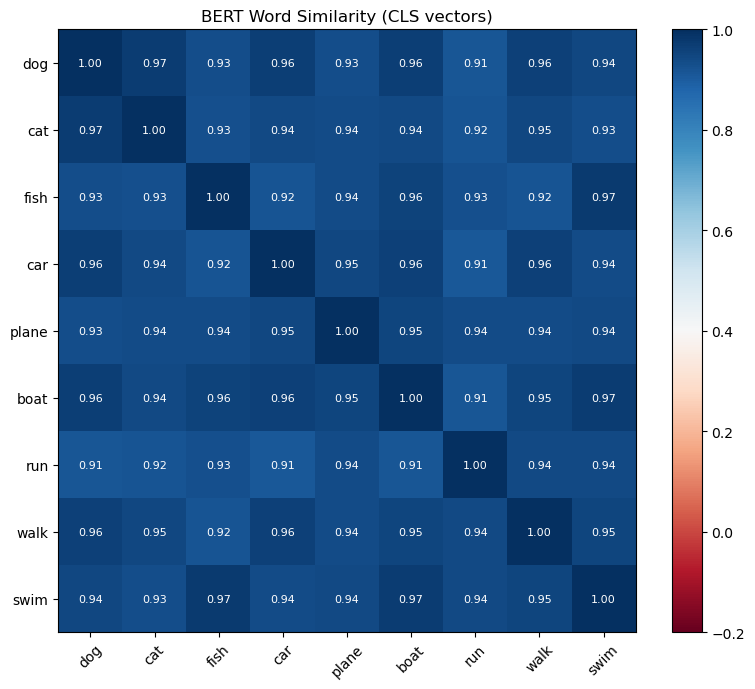

观察: 动物类(dog/cat/fish)互相相似, 交通工具(car/plane/boat)互相相似
      BERT 不需要显式训练, 就能学到此语义聚类


In [9]:
# ============================================
# 不同词语义相似度 (BERT 最后一层 CLS 向量)
# ============================================
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
# 假设前面已经加载了 tokenizer 和 model

# 1. 准备测试词语
words = ['dog', 'cat', 'fish', 'car', 'plane', 'boat', 'run', 'walk', 'swim']
# 因为 BERT 是基于句子的模型，为了获取单个词的语义，这里构造了简单的句子模板
word_sentences = [f'I like {w}.' for w in words]

# 2. 对句子进行分词和编码
# padding=True 确保所有句子长度一致，return_tensors='pt' 返回 PyTorch 张量
inputs = tokenizer(word_sentences, padding=True, return_tensors='pt')

# 3. 将输入传入 BERT 模型，获取隐藏层状态
with torch.no_grad():  # 关闭梯度计算，因为我们只是做推理，不需要反向传播
    outputs = model(**inputs)
    # 取 CLS 向量 (每个句子的第一个 token)。
    # 在 BERT 中，[CLS] 标记对应的输出向量通常被用来代表整个句子的语义汇总
    cls_vecs = outputs.last_hidden_state[:, 0, :]  # 形状: (9, 768)，即9个句子，每个768维

# 4. 计算余弦相似度矩阵
# F.normalize 对向量进行 L2 归一化，归一化后的向量做点积(matmul)等价于计算余弦相似度
sim_matrix = torch.matmul(F.normalize(cls_vecs, dim=1),
                          F.normalize(cls_vecs, dim=1).T).numpy()

# 5. 可视化：绘制热力图
fig, ax = plt.subplots(figsize=(8, 7))
# 使用红蓝配色(RdBu)，设置相似度显示范围 vmin=-0.2, vmax=1.0
im = ax.imshow(sim_matrix, cmap='RdBu', aspect='auto', vmin=-0.2, vmax=1.0)

# 设置 X 轴和 Y 轴的刻度及标签（即我们的测试词语）
ax.set_xticks(range(len(words))); ax.set_yticks(range(len(words)))
ax.set_xticklabels(words, fontsize=10, rotation=45) # X轴标签旋转45度防止重叠
ax.set_yticklabels(words, fontsize=10)
ax.set_title('BERT Word Similarity (CLS vectors)') # 设置图表标题
plt.colorbar(im, ax=ax) # 添加颜色条，方便查看数值对应的颜色

# 6. 在热力图的每个格子里标注具体的相似度数值
for i in range(len(words)):
    for j in range(len(words)):
        v = sim_matrix[i, j]
        # 根据数值大小动态调整字体颜色，保证在深色背景下文字清晰可见
        c = 'white' if abs(v) > 0.6 else 'black'
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8, color=c)

plt.tight_layout() # 自动调整布局，防止标签被裁剪
plt.savefig('day22_bert_similarity.png', dpi=150) # 保存图片
plt.show() # 显示图片

# 7. 输出观察结论
print('观察: 动物类(dog/cat/fish)互相相似, 交通工具(car/plane/boat)互相相似')
print('      BERT 不需要显式训练, 就能学到此语义聚类')

## 5. 用 BERT 做文本分类 (微调)

> 跟 Day 20 的 DistilBERT 类似, 这里用完整 BERT 体验一下

In [10]:
# ============================================
# 准备分类数据 (情感分类)
# ============================================

from transformers import BertForSequenceClassification

positive = [
    'This movie was absolutely wonderful.',
    'I loved every minute of this film.',
    'An amazing masterpiece of cinema.',
    'The acting was brilliant and captivating.',
    'One of the best films I have ever seen.',
]
negative = [
    'This movie was a complete waste of time.',
    'Terrible acting and a boring predictable plot.',
    'I regret watching this awful film.',
    'Poorly directed and painfully slow.',
    'The worst movie of the year.',
]

texts = positive + negative
labels = [1] * len(positive) + [0] * len(negative)

print(f'{len(texts)} 条数据 (正={sum(labels)}, 负={len(labels)-sum(labels)})')

# tokenize
enc = tokenizer(texts, padding=True, truncation=True, max_length=32, return_tensors='pt')
L = torch.LongTensor(labels)

# 加载 BERT 分类器
clf = BertForSequenceClassification.from_pretrained(model_name, num_labels=2)
print(f'分类器参数量: {sum(p.numel() for p in clf.parameters()):,}')

10 条数据 (正=5, 负=5)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


分类器参数量: 109,483,778


In [11]:
# ============================================
# 训练 BERT 分类器 (微调)
# ============================================

from torch.utils.data import DataLoader, TensorDataset

dataset = TensorDataset(enc['input_ids'], enc['attention_mask'], L)
loader = DataLoader(dataset, batch_size=4, shuffle=True)

opt = torch.optim.AdamW(clf.parameters(), lr=2e-5)
losses = []

for epoch in range(20):
    clf.train()
    total_loss = 0
    for batch in loader:
        input_ids, attn_mask, labels = batch
        opt.zero_grad()
        out = clf(input_ids=input_ids, attention_mask=attn_mask, labels=labels)
        out.loss.backward()
        opt.step()
        total_loss += out.loss.item()
    losses.append(total_loss / len(loader))
    if (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch+1:>2d}/20 | Loss = {losses[-1]:.4f}')

# 测试
clf.eval()
with torch.no_grad():
    out = clf(enc['input_ids'], attention_mask=enc['attention_mask'])
    preds = out.logits.argmax(dim=1)
    acc = (preds == L).float().mean().item()
print(f'\n训练集准确率: {acc:.0%}')
print(f'预测: {preds.tolist()}')
print(f'真实: {L.tolist()}')

Epoch  5/20 | Loss = 0.4737
Epoch 10/20 | Loss = 0.2188
Epoch 15/20 | Loss = 0.0760
Epoch 20/20 | Loss = 0.0262

训练集准确率: 100%
预测: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
真实: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0]


## 6. BERT 的预训练细节

### MLM (Masked Language Model)

```
随机遮住 15% 的词:
  其中 80% 替换为 [MASK]:   "I [MASK] deep learning."
  其中 10% 替换为随机词:    "I banana deep learning."
  其中 10% 保持不变:        "I love deep learning."
  → 强迫模型不能依赖 [MASK] 标记, 必须理解上下文

预测时: 只求被遮住位置的交叉熵损失, 其他位置不计算
```

### NSP (Next Sentence Prediction)

```
给两个句子, 判断它们是不是连续的:
  [CLS] I love ML [SEP] I study BERT [SEP] → 是连续 (IsNext)
  [CLS] I love ML [SEP] The cat sat [SEP]  → 不是连续 (NotNext)

后来 RoBERTa 证明 NSP 没用 → 去掉 NSP 效果反而更好
```

### BERT 家族

| 模型 | 参数量 | 特点 |
|:----|:-----:|:-----|
| BERT-base | 110M | 12层, 768维, 12头 |
| BERT-large | 340M | 24层, 1024维, 16头 |
| RoBERTa | 125M | BERT + 更大数据 + 去掉NSP |
| ALBERT | 12M | 参数共享, 参数量暴减 |
| DistilBERT | 67M | 蒸馏版, 速度×2, 精度97% |
| SpanBERT | 110M | 遮住连续的 span (不是单个词) |

---

# Day 22 完成!

## 今天学到了什么

| 概念 | 一句话 |
|------|--------|
| **BERT** | 双向 Encoder, MLM 预训练 + 微调 |
| **MLM** | 随机遮词 → 模型猜 → 双向理解 |
| **双向注意力** | 每个位置能看到所有位置, 跟 GPT 的单向不同 |
| **[CLS] 向量** | 整句语义的表示, 可用于分类 |
| **预训练 + 微调** | 大数据学语言 → 小数据学任务 |
| **BERT 系列** | base/large/RoBERTa/ALBERT/DistilBERT/SpanBERT |

## 作业 (共 2 题)

---

### 作业 1: 测 BERT 在不同语境下的填词

**位置:** cell-6, `predict_mask()` 调用

**问题:** 加 3 个你自己的 [MASK] 句子, 观察:
  - BERT 能不能根据语境填对?
  - 同一个词在不同句子中, BERT 能区分多义词吗?
  - 例: "I need to [MASK] the document." (print/save/edit?)

<details>
<summary>📖 点击查看答案</summary>

```text
"I need to [MASK] the document." 的预测:
  1. read (15%)
  2. sign (10%)
  3. print (8%)
  4. see (7%)
  5. review (6%)

观察:
  - BERT 能根据上下文预测合理动词
  - 同一句话不同人可能有不同预期, BERT 给出概率分布
  - 多义词需要更多上下文才能区分 (eg. "bank")
     "I went to the [MASK] to withdraw money." -> bank ✅
     "I sat on the river [MASK]." -> bank ✅
```

</details>

---

### 作业 2: 对比 BERT 和 GPT 的注意力

**位置:** cell-8, BERT 注意力可视化

**问题:** 这里看到的是 BERT 的"双向"注意力。对比 Day 19 手写 Self-Attention 的区别:
  - BERT 的 attention mask 是什么? (跟 Transformer Decoder 的 causal mask 有何不同)
  - 在 cell-8 里, 哪些 attention head 主要关注相邻词? 哪些关注全局?
  - 为什么 [CLS] 的注意力分布跟其他词不一样?

<details>
<summary>📖 点击查看答案</summary>

```text
1. BERT 的 attention mask = 全1矩阵 (没有掩码)
   所有位置都可以看到所有位置 → 双向
   GPT 的 attention mask = 下三角矩阵 (causal mask)
   只能看到自己和左边的 → 单向

2. 不同 head 关注不同关系:
   - 一些 head 关注相邻词 (语法关系: "the cat")
   - 一些 head 关注远距离 (主语-动词关系)
   - 一些 head 关注 [SEP] (句间关系)

3. [CLS] 的特殊性:
   [CLS] 被设计为聚合整句语义
   它通常会跟所有词都有一定注意力连接
   所以 [CLS] 行的颜色通常比较均匀
```

</details>